# **Evaluación de modelos de machine learning para la aprovación de créditos bancarios**

---

En este proyecto se realiza una comparación entre distintos modelos de machine learning utilizando un conjunto de datos bancarios enfocado en la aprobación de créditos personales.

Inicialmente, se implementa un modelo de regresión logística empleando variables predictivas seleccionadas con base en diferentes criterios. Posteriormente, se comparan los siguientes modelos:

*   **Regresión logística**
*   **Árbol de decisión**
*   **Gradient Boosting Classifier**
*   **Support Vector Machine**

Los resultados obtenidos permiten identificar qué modelo presenta un mejor desempeño en este contexto.

# **Librerias**

In [219]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# **Análisis del dataset "bank_loan"**

In [220]:
# Datos

Bank_Loan = pd.read_csv('bank_loan.csv')
Bank_Loan

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [221]:
# Dimensiones del dataset

print(f"Número de filas: {Bank_Loan.shape[0]}")
print(f"Número de columnas: {Bank_Loan.shape[1]}")

Número de filas: 5000
Número de columnas: 14


In [222]:
Bank_Loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [223]:
Bank_Loan.head()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [224]:
# Valores nulos

missing_values = (Bank_Loan.isnull().sum() * 100) / Bank_Loan.shape[0]
missing_values = missing_values[missing_values > 0].sort_values(ascending = False)

print(missing_values)

Series([], dtype: float64)


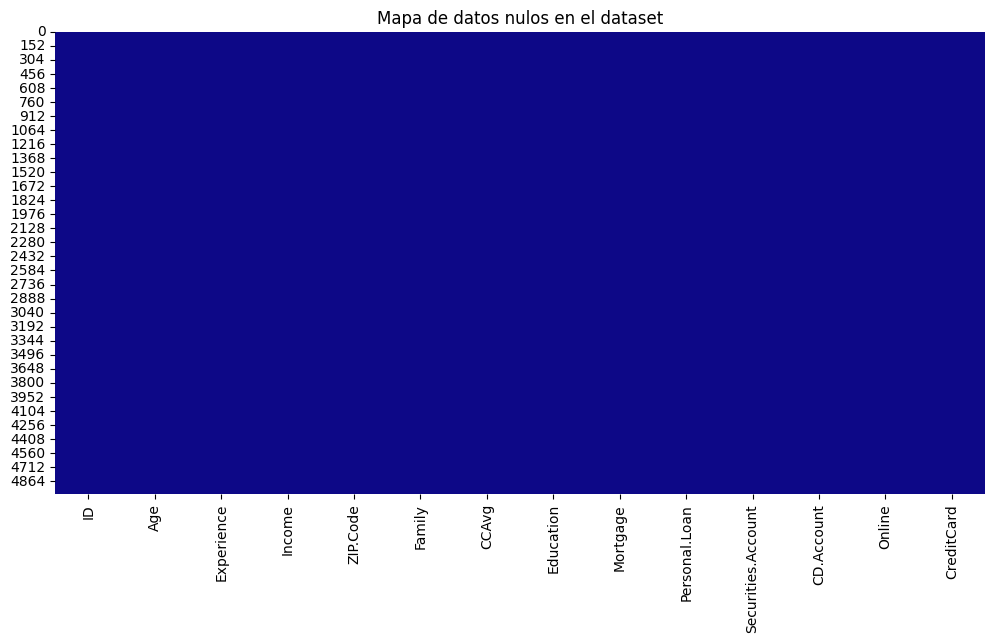

In [225]:
# Mapa de valores nulos

plt.figure(figsize=(12, 6))
sns.heatmap(Bank_Loan.isnull(), cbar = False, cmap = "plasma")
plt.title('Mapa de datos nulos en el dataset')
plt.show()

Tras revisar el dataset `Bank_Loan`:

- No existen valores nulos en ninguna de las columnas del dataset.

- Tanto el análisis numérico como el mapa de calor indican que todas las observaciones están completas y no presentan datos faltantes.

- No es necesario realizar imputaciones, eliminaciones ni tratamientos adicionales para valores perdidos.

- Podemos continuar directamente con el análisis exploratorio y el modelado, ya que la calidad de los datos es adecuada.

# **Análisis de variables para el módelo de regresión logística**


## **Análisis de variable objetivo `Personal.Loan`**

In [226]:
# Conteo absoluto

print(Bank_Loan['Personal.Loan'].value_counts())

# Conteo relativo (porcentaje)

print(Bank_Loan['Personal.Loan'].value_counts(normalize = True) * 100)

Personal.Loan
0    4520
1     480
Name: count, dtype: int64
Personal.Loan
0    90.4
1     9.6
Name: proportion, dtype: float64


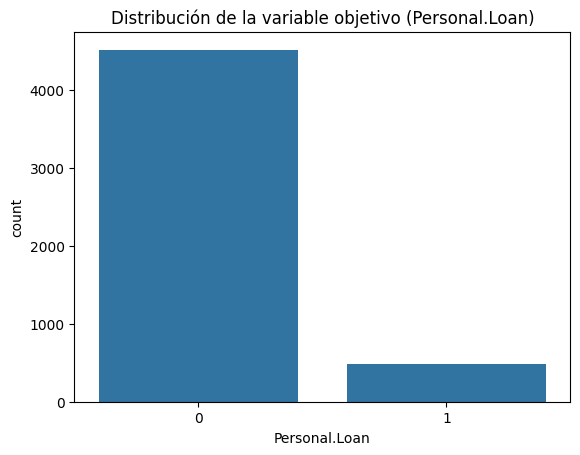

In [227]:
# Gráfico de la variable objetivo

sns.countplot(data = Bank_Loan, x = 'Personal.Loan')
plt.title('Distribución de la variable objetivo (Personal.Loan)')
plt.show()

El gráfico muestra la distribución de la variable objetivo `Personal.Loan`, donde:

- El valor 0 representa a los clientes que no fueron aprobados para un préstamo personal.

- El valor 1 representa a los clientes que sí fueron aprobados para un préstamo personal.

Podemos observar que existe un desbalance importante en las clases:

- La mayoría de los clientes no fueron aceptados para un préstamo personal.

- Solo un pequeño porcentaje de los clientes sí fueron aceptados un préstamo personal.

## **Correlación entre las variables**

In [228]:
# Calculamos la matriz de correlaciones completa
corr = Bank_Loan.corr(numeric_only=True)

# Nos quedamos solo con la correlación contra 'Personal.Loan'
corr_output = corr['Personal.Loan']

# Ordenamos de mayor a menor por valor absoluto
corr_output_sorted = corr_output.abs().sort_values(ascending=False)

# Mostramos las correlaciones originales ordenadas
final_corr_output = corr_output.loc[corr_output_sorted.index]

# Mostramos ordenado
print(final_corr_output)

Personal.Loan         1.000000
Income                0.502462
CCAvg                 0.366889
CD.Account            0.316355
Mortgage              0.142095
Education             0.136722
Family                0.061367
ID                   -0.024801
Securities.Account    0.021954
Age                  -0.007726
Experience           -0.007413
Online                0.006278
CreditCard            0.002802
ZIP.Code              0.000107
Name: Personal.Loan, dtype: float64


## **Análisis variables predictoras**


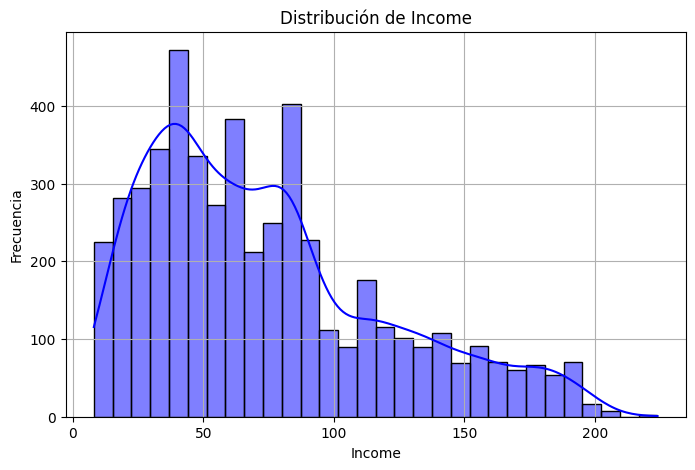

In [229]:
plt.figure(figsize = (8, 5))
sns.histplot(Bank_Loan['Income'], kde = True, color = 'blue', bins = 30)
plt.title('Distribución de Income')
plt.xlabel('Income')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

**El ingreso anual de los clientes.**

La mayoría de los clientes tiene ingresos relativamente bajos (concentrados entre 20 y 70). A medida que el ingreso aumenta, el número de clientes disminuye considerablemente. Esto indica una distribución sesgada a la derecha (asimetría positiva).

Importante: Hay pocos clientes con ingresos muy altos.

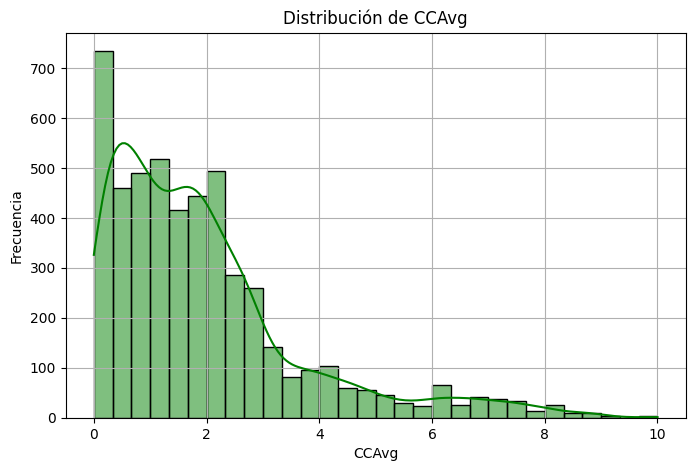

In [230]:
plt.figure(figsize = (8, 5))
sns.histplot(Bank_Loan['CCAvg'], kde = True, color = 'green', bins = 30)
plt.title('Distribución de CCAvg')
plt.xlabel('CCAvg')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

**El gasto promedio mensual con tarjeta de crédito.**

La mayoría de los clientes gasta poco con su tarjeta de crédito (entre 0 y 2). La frecuencia disminuye rápidamente conforme aumenta el gasto. Esto indica que muchos clientes apenas usan su tarjeta de crédito y solo unos pocos tienen gastos elevados.

Importante: Hay alta concentración en gastos bajos.

/tmp/ipython-input-3723927489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'CD.Account', data = Bank_Loan, palette = 'Set2')


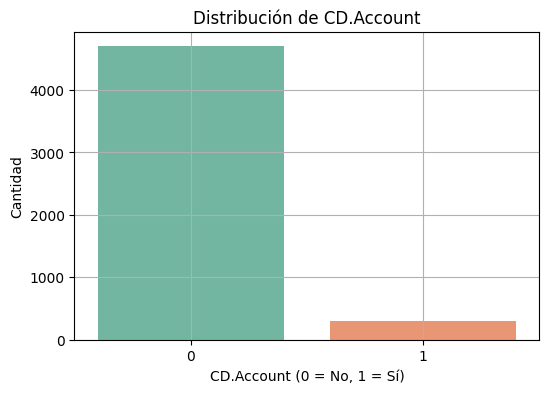

In [231]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'CD.Account', data = Bank_Loan, palette = 'Set2')
plt.title('Distribución de CD.Account')
plt.xlabel('CD.Account (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.grid(True)
plt.show()

**Variable binaria: 1 si el cliente tiene una cuenta de depósito a plazo, 0 si no.**

La mayoría de los clientes no tiene una cuenta de certificado de depósito (valor 0). Solo una pequeña fracción posee una (valor 1).

Importante: Es una variable muy desbalanceada con más clientes sin `CD.Account`.

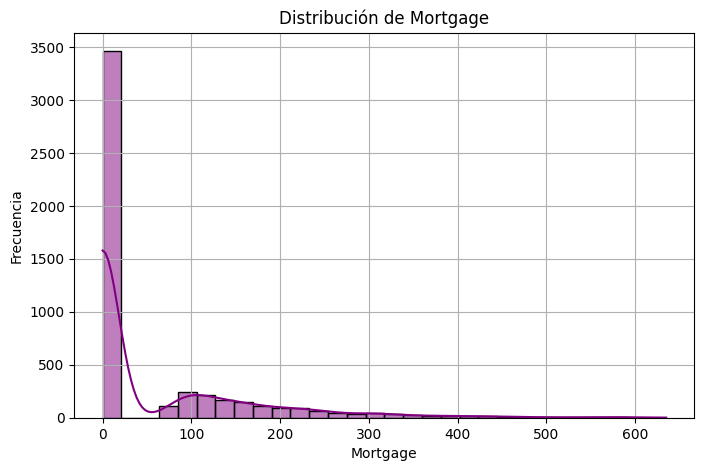

In [232]:
plt.figure(figsize = (8, 5))
sns.histplot(Bank_Loan['Mortgage'], kde = True, color = 'purple', bins = 30)
plt.title('Distribución de Mortgage')
plt.xlabel('Mortgage')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

**El monto del préstamo hipotecario.**


La gran mayoría de los clientes no tiene hipoteca (valor cerca de 0). Sin embargo entre quienes sí tienen, existen montos bastante variados. Es una distribución fuertemente sesgada hacia la derecha.

Importante: El hecho de no tener hipoteca es muy común entre los clientes.



/tmp/ipython-input-1005282118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Education', data = Bank_Loan, palette = 'coolwarm')


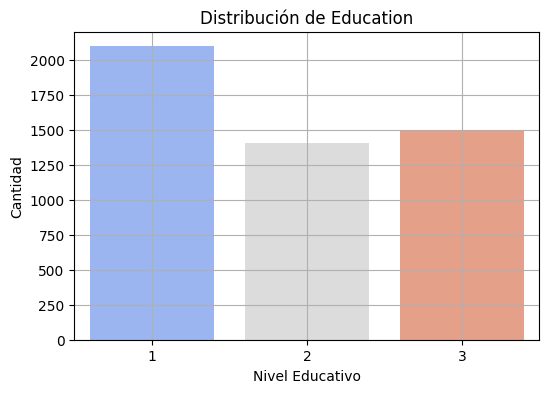

In [233]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'Education', data = Bank_Loan, palette = 'coolwarm')
plt.title('Distribución de Education')
plt.xlabel('Nivel Educativo')
plt.ylabel('Cantidad')
plt.grid(True)
plt.show()

**1 = Undergraduate, 2 = Graduate, 3 = Advanced/Professional.**


El grupo más numeroso tiene nivel Undergraduate (1). Los niveles Graduate (2) y Advanced (3) están más equilibrados, pero son claramente menores que Undergraduate.

Importante: Hay más personas con educación básica universitaria.



## **Selección y justificación de variables numéricas**

Dentro del análisis inicial, se observó que el dataset `Bank_Loan` cuenta con variables numéricas que reflejan características financieras y demográficas de los clientes. Estas variables proporcionan información relevante sobre los hábitos de consumo, niveles de ingreso, capacidad de endeudamiento y características personales que pueden influir en la solicitud o aprobación de un préstamo personal (`Personal.Loan`).

En particular, se consideraron las siguientes variables numéricas:

- `Income`: Representa el ingreso anual del cliente.

- `CCAvg`: Promedio mensual de gasto con tarjeta de crédito.

- `Mortgage`: Monto de hipoteca existente.

- `Education`: Nivel educativo alcanzado (1 = Undergraduate, 2 = Graduate, 3 = Advanced).

- `Family`: Número de miembros en la familia.

- `CD.Account`: Indica la existencia de una cuenta de certificado de depósito.

Estas variables fueron seleccionadas basándonos en los siguientes criterios:

- **Correlación con la variable objetivo** (`Personal.Loan`)**:** Se calculó la matriz de correlaciones y se priorizaron aquellas variables que mostraron un mayor valor absoluto de correlación respecto a la variable objetivo.

- **Interpretabilidad financiera:** Se eligieron variables que tienen sentido económico o comportamental relacionado con la capacidad y propensión a solicitar un préstamo.

- **No redundancia:** Se evitó incluir variables que fueran redundantes entre sí o que no aportaran valor adicional relevante.

Cada tipo de variable aporta una perspectiva distinta:

- `Income` y `CCAvg` permiten evaluar la capacidad económica y los hábitos de consumo del cliente.

- `Mortgage` refleja cargas financieras existentes que podrían afectar la toma de nuevos créditos.

- `Education` y `Family` proporcionan contexto demográfico que puede estar asociado a necesidades financieras diferentes.

- `CD.Account` sugiere un perfil financiero más conservador lo cual puede influir en la probabilidad de solicitar un préstamo.

Este proceso permitió construir un subconjunto de variables explicativas robusto, que combina poder predictivo con sentido financiero, mejorando así la calidad y la interpretabilidad del modelo de regresión logística.

## **Variables predictivas seleccionadas**

`Income`:

Correlación positiva (0.52).

Un mayor ingreso se asocia con una mayor probabilidad de solicitar un préstamo personal. Clientes con ingresos más altos pueden ser más elegibles o interesados en este producto financiero.

`CCAvg`:

Correlación positiva (0.36).

El gasto promedio mensual en tarjetas de crédito es un indicador importante de comportamiento financiero. Usuarios que gastan más tienden a necesitar productos de crédito adicionales como préstamos personales.

`CD.Account`:

Correlación positiva moderada (0.31).

La tenencia de un certificado de depósito está relacionada con la solicitud de préstamos por mayores niveles de ahorro o gestión patrimonial.

`Mortgage`:

Correlación positiva (0.14).

Tener un saldo hipotecario indica un historial crediticio activo lo cual puede aumentar la probabilidad de solicitar un préstamo personal como complemento financiero.

`Education:`

Correlación positiva (0.13).

Un mayor nivel educativo podría estar relacionado con mayores ingresos o necesidades financieras más complejas, justificando su inclusión en el modelo.

**Notas:**

- `Family`, `Age`, `Experience`, `Securities.Account`, `Online`, `CreditCard` y `ZIP.Code` se descartaron tener baja correlación.

- `ID` tampoco se incluye porque es un identificador único.

# **Análisis bivariado**

## `Income` vs `Personal.Loan`

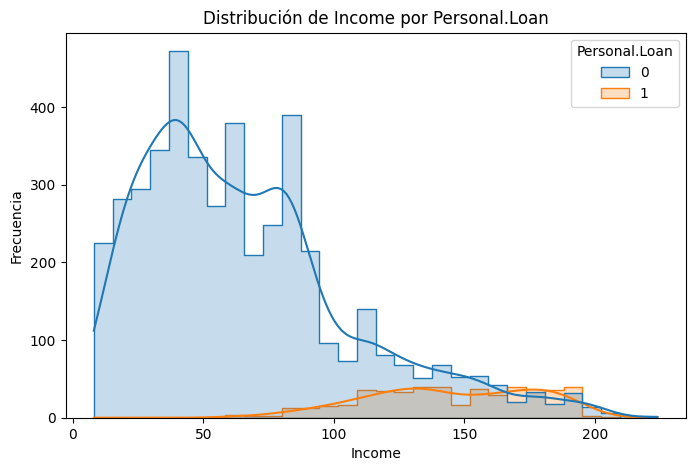

In [234]:
plt.figure(figsize = (8,5))
sns.histplot(data = Bank_Loan, x = 'Income', hue = 'Personal.Loan', bins = 30, kde = True, element = 'step')
plt.title('Distribución de Income por Personal.Loan')
plt.xlabel('Income')
plt.ylabel('Frecuencia')
plt.show()

Se observa que los clientes con mayores ingresos tienen una mayor proporción de préstamos aprobados (`Personal.Loan` = 1). La distribución de los clientes sin préstamo (0) es mayoritaria en ingresos bajos y decrece conforme aumenta el ingreso, mientras que los clientes con préstamo se concentran más en niveles altos de ingresos.

## `CCAvg` vs `Personal.Loan`

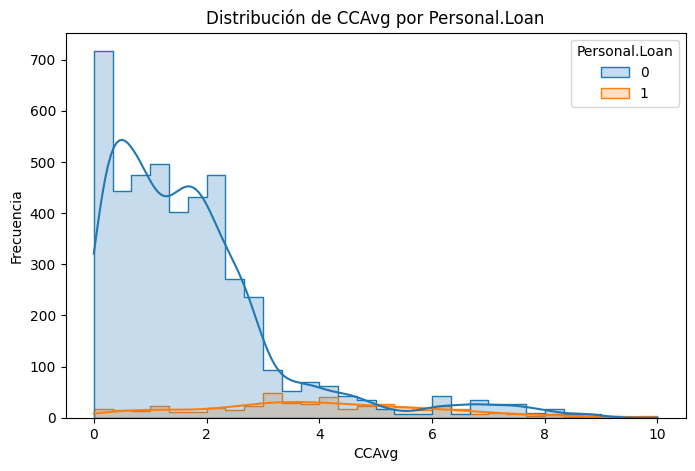

In [235]:
plt.figure(figsize = (8,5))
sns.histplot(data = Bank_Loan, x = 'CCAvg', hue = 'Personal.Loan', bins = 30, kde = True, element = 'step')
plt.title('Distribución de CCAvg por Personal.Loan')
plt.xlabel('CCAvg')
plt.ylabel('Frecuencia')
plt.show()

El gasto promedio en tarjeta de crédito (`CCAvg`) es mayor en los clientes que aceptaron un préstamo (`Personal.Loan` = 1). Los clientes que no contrataron préstamos tienden a concentrarse en niveles bajos de `CCAvg`, mientras que conforme aumenta el gasto en tarjeta, la proporción de clientes con préstamos también aumenta.

## `Mortgage` vs `Personal.Loan`

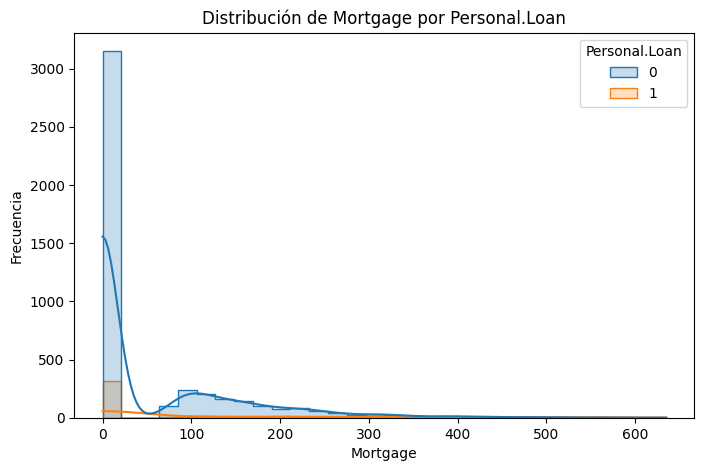

In [236]:
plt.figure(figsize = (8,5))
sns.histplot(data = Bank_Loan, x = 'Mortgage', hue = 'Personal.Loan', bins = 30, kde = True, element = 'step')
plt.title('Distribución de Mortgage por Personal.Loan')
plt.xlabel('Mortgage')
plt.ylabel('Frecuencia')
plt.show()

La mayoría de los clientes no tiene hipotecas (`Mortgage` = 0) tanto entre quienes aceptaron como quienes no aceptaron préstamos. Sin embargo entre quienes sí tienen hipoteca, la probabilidad de aceptar un préstamo parece incrementarse ligeramente a medida que crece el monto de la hipoteca.

## `CD.Account` vs `Personal.Loan`

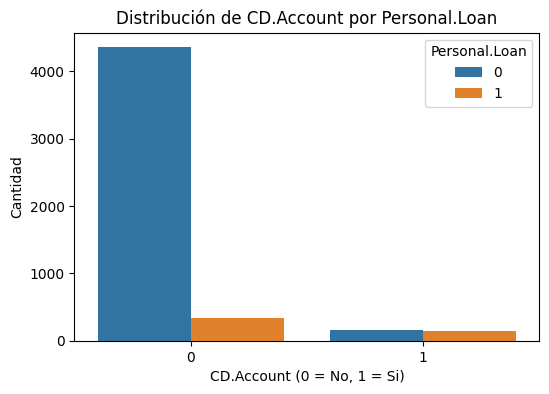

In [237]:
plt.figure(figsize = (6,4))
sns.countplot(data = Bank_Loan, x = 'CD.Account', hue = 'Personal.Loan')
plt.title('Distribución de CD.Account por Personal.Loan')
plt.xlabel('CD.Account (0 = No, 1 = Si)')
plt.ylabel('Cantidad')
plt.show()

Se aprecia una fuerte relación positiva: los clientes que tienen una cuenta de certificados de depósito (`CD.Account` = 1) presentan una proporción mucho mayor de aceptación de préstamos comparado con quienes no tienen cuenta. Es una de las variables más discriminantes.

## `Education` vs `Personal.Loan`

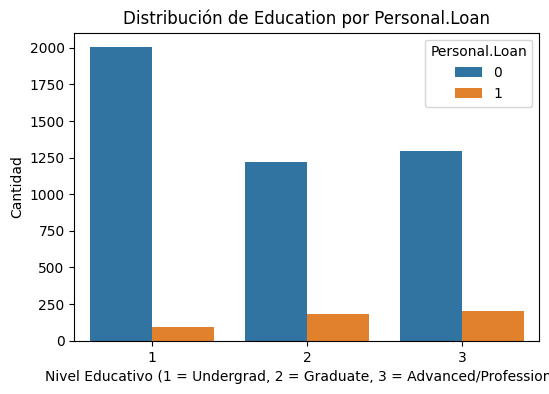

In [238]:
plt.figure(figsize = (6,4))
sns.countplot(data = Bank_Loan, x = 'Education', hue = 'Personal.Loan')
plt.title('Distribución de Education por Personal.Loan')
plt.xlabel('Nivel Educativo (1 = Undergrad, 2 = Graduate, 3 = Advanced/Professional)')
plt.ylabel('Cantidad')
plt.show()

A mayor nivel educativo mayor es la proporción de aceptación de préstamos. Los clientes con nivel 3 (Advanced/Professional) presentan una participación mayor en la aceptación del préstamo en comparación con aquellos de nivel 1 (Undergrad).

# **Regresión logística**

## **Modelo**

In [239]:
X = Bank_Loan[
    [
        'Income',
        'CCAvg',
        'CD.Account',
        'Mortgage',
        'Education'
    ]
]

y = Bank_Loan['Personal.Loan']

In [240]:
X = pd.get_dummies(X, columns = ['Education'], drop_first = True)

In [241]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y
)

In [242]:
X_train_sm = sm.add_constant(X_train)

In [243]:
X_train_sm = X_train_sm.astype(float)
y_train = y_train.astype(float)

In [244]:
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.132182
         Iterations 9


In [245]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:          Personal.Loan   No. Observations:                 3500
Model:                          Logit   Df Residuals:                     3493
Method:                           MLE   Df Model:                            6
Date:                Sat, 10 Jan 2026   Pseudo R-squ.:                  0.5820
Time:                        20:30:28   Log-Likelihood:                -462.64
converged:                       True   LL-Null:                       -1106.7
Covariance Type:            nonrobust   LLR p-value:                3.978e-275
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -11.4507      0.525    -21.824      0.000     -12.479     -10.422
Income          0.0539      0.003     17.547      0.000       0.048       0.060
CCAvg           0.1593      0.048      3.298    

### **Interpretación del modelo de regresión logística**

Se realizó un modelo de regresión logística utilizando 3,500 observaciones con el objetivo de identificar los factores que influyen en la probabilidad de que un cliente contrate un Préstamo Personal (`Personal.Loan`).

El modelo alcanzó un **Pseudo R^2** de 0.5820 lo cual indica un buen ajuste considerando que en modelos predictivos basados en datos reales no suele esperarse un ajuste perfecto.

Además, el **p-valor** asociado al test de verosimilitud (LLR p-value = 3.978e-275) indíca que el modelo es estadísticamente significativo.

### **Interpretación de las variables**

Las variables estadísticamente significativas (p-valor < 0.05) obtenidas fueron:

**Income:**

El coeficiente es positivo (0.0539) indicando que a mayor ingreso mayor probabilidad de contratar un préstamo personal.

**CCAvg:**

El coeficiente es positivo (0.1593) mostrando que mayores gastos promedio con tarjeta de crédito aumentan la probabilidad de tomar un préstamo.

**CD.Account:**

El coeficiente positivo (2.3947) indica que tener una cuenta de certificado de depósito se asocia fuertemente con una mayor probabilidad de adquirir un préstamo.

**Mortgage:**

El coeficiente positivo (0.0013) implica que mayores montos de hipoteca también elevan la probabilidad de solicitar un préstamo.

**Education_2 (Graduate):**

El coeficiente positivo (4.1037) muestra que las personas con nivel de educación de posgrado tienen mayor tendencia a contratar préstamos comparado con quienes solo tienen estudios de pregrado (Undergrad).

**Education_3 (Advanced/Professional):**

El coeficiente positivo (4.0411) significa que quienes tienen formación avanzada o profesional tienen aún más probabilidad de contratar un préstamo que los de menor nivel educativo.

**Nota:**

Aunque varios coeficientes son positivos su magnitud debe ser interpretada con cuidado ya que dependen de las escalas originales de las variables (por ejemplo, ingresos en miles de dólares, gastos promedio, etc.).

### **Matriz de confusión y métricas básicas**

In [246]:
# Aumentamos iteraciones para asegurar convergencia

logreg = LogisticRegression(max_iter = 1000, solver = 'lbfgs')
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [247]:
y_pred = logreg.predict(X_test)

In [248]:
cm = confusion_matrix(y_test, y_pred)

In [249]:
print("Matriz de Confusión:")
print(cm)

Matriz de Confusión:
[[1342   14]
 [  50   94]]


In [250]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division = 0)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [251]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.9573
Precision: 0.8704
Recall: 0.6528
F1-Score: 0.7460


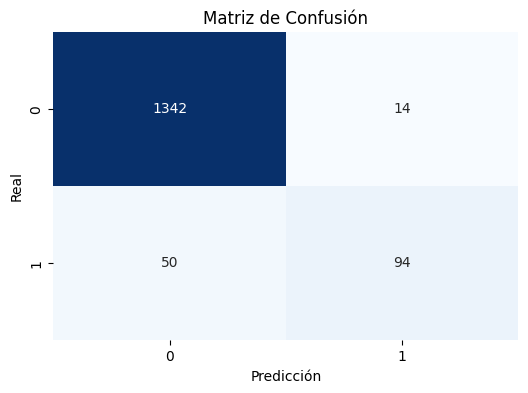

In [252]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", cbar = False)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

**Matriz de Confusión**

- 1342 verdaderos negativos (clientes que no solicitaron préstamo y fueron correctamente clasificados).

- 94 verdaderos positivos (clientes que sí solicitaron préstamo y fueron correctamente clasificados).

- 50 falsos negativos (clientes que sí solicitaron préstamo pero fueron clasificados como que no lo hicieron).

- 14 falsos positivos (clientes que no solicitaron préstamo pero fueron clasificados como si lo hubieran hecho).

Esto indica que el modelo logra identificar correctamente la mayoría de los clientes, especialmente los que no solicitaron un préstamo.

**Métricas Clave**

**Accuracy (Exactitud): 0.9573**

- El 95.73% de las predicciones fueron correctas.

- El modelo es altamente preciso en general.

**Precision: 0.8704**

- Cuando el modelo predice que alguien tomará un préstamo, tiene un 87.04% de probabilidad de acertar.

- Esto es importante para minimizar falsos positivos.

**Recall (Sensibilidad): 0.6528**

- El modelo detecta correctamente el 65.28% de todos los casos verdaderos de solicitud de préstamo.

- Hay margen de mejora, pues algunos clientes que sí solicitaron préstamo no fueron detectados (falsos negativos).

**F1-Score: 0.7460**

- Balance entre precisión y recall.

- Un valor de 0.746 indica un desempeño razonablemente bueno para un dataset desbalanceado.

### **Curva $ROC$ y $AUC$**

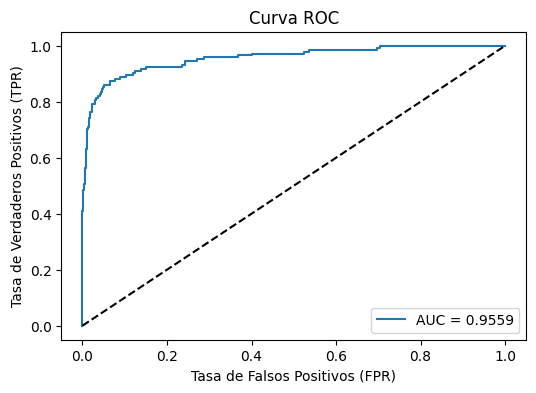

In [253]:
# Probabilidades de clase 1

y_pred_proba = logreg.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Curva ROC y AUC**

El AUC (Área Bajo la Curva ROC) es 0.9559.

- Esto representa una capacidad de discriminación excelente del modelo.

- Cuanto más cerca de 1 mejor se distingue entre clientes que solicitaron y no solicitaron préstamos.

La curva ROC también muestra que el modelo es robusto manteniendo una alta tasa de verdaderos positivos con una baja tasa de falsos positivos.

**Conclusión del modelo**

- El modelo tiene una alta exactitud y una excelente capacidad para distinguir entre clases.

- Tiene una alta precisión (evita falsos positivos), pero el recall podría mejorarse para capturar más casos de personas que realmente toman el préstamo.

- El AUC de 0.9559 respalda que el modelo discrimina de manera muy efectiva entre clases.

## **Oversampling**

In [254]:
smote = SMOTE(random_state = 42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [255]:
logreg = LogisticRegression(max_iter = 1000)
logreg.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [256]:
y_pred = logreg.predict(X_test)

### **Matriz de confusión y métricas básicas con SMOTE**

In [257]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Matriz de Confusión:")
print(cm)

Matriz de Confusión:
[[1260   96]
 [  19  125]]


In [258]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.9233
Precision: 0.5656
Recall: 0.8681
F1-Score: 0.6849


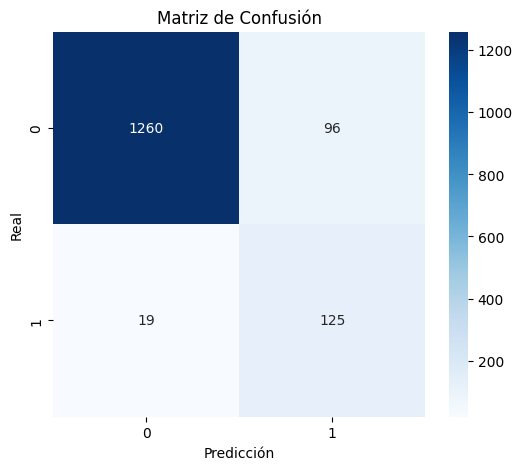

In [259]:
plt.figure(figsize = (6,5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

**Accuracy (Exactitud):** 0.9233

- El 92.33% de las predicciones fueron correctas.

- El modelo tiene un desempeño general alto.

**Precision:** 0.5656

- Cuando el modelo predice que alguien tomará un préstamo, tiene un 56.56% de probabilidad de acertar.

- La precisión bajó respecto al modelo anterior, indicando más falsos positivos.

**Recall (Sensibilidad):** 0.8681

- El modelo detecta correctamente el 86.81% de los casos verdaderos de solicitud de préstamo.

- Se logró una mejora considerable en la sensibilidad, minimizando los falsos negativos.

**F1-Score:** 0.6849

- Balance entre precisión y recall.

- Un valor de 0.6849 indica un desempeño decente, aunque ligeramente inferior al modelo original en balance.

### **Curva $ROC$ y $AUC$ con SMOTE**

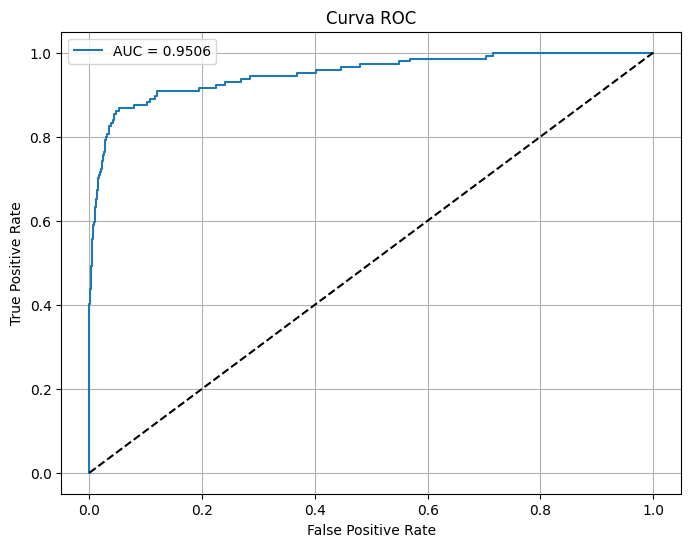

In [260]:
y_pred_prob = logreg.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize = (8,6))
plt.plot(fpr, tpr, label = f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid()
plt.show()

**Curva ROC y AUC**

- El AUC (Área Bajo la Curva ROC) es 0.9500.

- Esto representa una excelente capacidad de discriminación entre clientes que solicitaron y no solicitaron préstamo.

- La curva ROC muestra que el modelo sigue siendo robusto con una alta tasa de verdaderos positivos y baja tasa de falsos positivos.

### **Interpretación de modelo después de oversampling (SMOTE)**

El modelo tuvo las siguientes mejoras:

- Después de SMOTE mejora notablemente el Recall capturando más clientes que solicitaron un préstamo.

- La precisión disminuyó y hay más casos donde el modelo predice un préstamo cuando realmente no era necesario.

- Si la prioridad del negocio es minimizar el riesgo de no identificar a un cliente que realmente tomará un préstamo (preferimos detectar todos los positivos aunque tengamos más falsos positivos) el modelo con SMOTE es más adecuado.

- Sin embargo si se quiere más precisión en las aprobaciones (menos falsos positivos) el modelo original sin oversampling era mejor.

## **Supuestos de Regresión**

### **Cálculo de $VIF$ para verificar multicolinealidad**

In [261]:
# Nos aseguramos que todas las variables de entrenamiento sean numéricas

X_train_vif = X_train.copy()
X_train_vif = X_train_vif.apply(pd.to_numeric)

# Agregamos una constante para VIF

X_train_vif = sm.add_constant(X_train_vif)

# Verificamos que no haya valores nulos nuevamente

print("Valores nulos por columna:")
print(X_train_vif.isnull().sum())

Valores nulos por columna:
const          0
Income         0
CCAvg          0
CD.Account     0
Mortgage       0
Education_2    0
Education_3    0
dtype: int64


In [262]:
# Nos aseguramos que el tipo de dato sea float

X_train_vif = X_train_vif.astype(float)

In [263]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]

# Mostramos los resultados

print("VIF de cada variable:")
print(vif_data)

VIF de cada variable:
      Variable       VIF
0        const  6.162053
1       Income  1.820424
2        CCAvg  1.700951
3   CD.Account  1.043445
4     Mortgage  1.044012
5  Education_2  1.252332
6  Education_3  1.247349


Se calculó el Factor de Inflación de la Varianza (VIF) para cada variable predictora del modelo con el objetivo de verificar la existencia de multicolinealidad.

**Interpretación:**

- Valores de VIF menores a 5 indican que no existe un problema de multicolinealidad entre las variables predictoras.

- Todas las variables predictoras presentan valores de VIF cercanos a 1 lo cual confirma la ausencia de multicolinealidad.

- El valor elevado de VIF en const (6.162) corresponde a la constante del modelo (intercepto) y no a una variable predictora.

Con base en lo anterior se cumple el supuesto de no multicolinealidad. El modelo de regresión logística no presenta redundancia entre las variables predictoras.

### **Código para comprobar la linealidad del logit (Método $Box-Tidwell$)**

In [264]:
# Creamos una copia de X_train
X_train_bt = X_train.copy()

# Convertimos a tipo numérico
X_train_bt = X_train_bt.astype(float)

# Reemplazamos ceros o valores negativos para evitar problemas en el log
X_train_bt = X_train_bt.applymap(lambda x: x if x > 0 else 1e-6)

# Creamos variables
for col in X_train_bt.columns:
    if col != 'const':
        X_train_bt[f'{col}_log'] = X_train_bt[col] * np.log(X_train_bt[col])

# Calculamos matriz de correlación
corr_matrix = X_train_bt.corr().abs()

# Eliminamos variables altamente correlacionadas (>0.95) para evitar colinealidad
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_train_bt_clean = X_train_bt.drop(columns=to_drop)

# Ajustamos
logit_bt = sm.Logit(y_train, X_train_bt_clean)
result_bt = logit_bt.fit()

# Mostramos p-valores de las variables de interacción
print("\nP-valores de la prueba Box-Tidwell (linealidad del logit):")
print(result_bt.pvalues)


Optimization terminated successfully.
         Current function value: 0.458437
         Iterations 6

P-valores de la prueba Box-Tidwell (linealidad del logit):
Income         4.321758e-20
CCAvg          7.189807e-01
CD.Account     1.383616e-31
Mortgage       1.166087e-03
Education_2    4.961826e-41
Education_3    5.365509e-43
dtype: float64


/tmp/ipython-input-2989000190.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train_bt = X_train_bt.applymap(lambda x: x if x > 0 else 1e-6)


Se realizó la prueba Box-Tidwell para verificar el supuesto de linealidad entre las variables independientes continuas y el logit de la variable objetivo (`Personal.Loan`). En esta prueba un **p-valor significativo (p < 0.05)** indica que el supuesto de linealidad se viola.

**Resultados de los p-valores para la prueba Box-Tidwell:**

- `Income`: 4.32e-20 (significativo)
- `CCAvg`: 0.7190 (no significativo)
- `CD.Account`: 1.38e-31 (significativo)
- `Mortgage`: 0.0012 (significativo)
- `Education_2`: 4.96e-41 (significativo)
- `Education_3`: 5.37e-43 (significativo)

**Conclusiones**

- Las variables `Income`, `CD.Account`, `Mortgage`, `Education_2` y `Education_3` presentan p-valores significativos (p < 0.05). Esto indica que para estas variables se viola el supuesto de linealidad del logit. Su relación con la probabilidad logarítmica de `Personal.Loan` no es estrictamente lineal.

- La variable `CCAvg` tiene un p-valor no significativo (p = 0.7190). Esto sugiere que para `CCAvg` el supuesto de linealidad con el logit se cumple.

El supuesto de linealidad del logit no se cumple para la mayoría de las variables predictoras continuas en el modelo.

Esto significa que la calidad de las predicciones y la interpretación de los coeficientes podrían mejorarse. Se podría considerar:

  - Aplicar transformaciones a las variables que violan el supuesto.
  - Explorar modelos que no asumen linealidad en el logit como árboles de decisión.

### **Independencia de Errores**

In [265]:
from statsmodels.stats.stattools import durbin_watson

In [266]:
residuals = y_train - result.predict(X_train_sm)

In [267]:
# Aplicamos la prueba de Durbin-Watson

dw_statistic = durbin_watson(residuals)

# Mostramos el resultado

print(f"Estadístico de Durbin-Watson: {dw_statistic:.4f}")

Estadístico de Durbin-Watson: 1.9879


- El estadístico de Durbin-Watson toma valores entre 0 y 4.

- Un valor cercano a 2 indica ausencia de autocorrelación en los errores lo cual es deseable en un modelo de regresión.

- Un valor menor a 2 indica autocorrelación positiva (errores consecutivos tienden a ser similares).

- Un valor mayor a 2 indicaría autocorrelación negativa (errores consecutivos tienden a ser opuestos).

Con base en esto el valor obtenido (1.9879) es cercano a 2 por lo que se cumple el supuesto de independencia de errores en el modelo.

### **Ausencia de Valores Atipicos**

In [268]:
# Calculamos el leverage y la Cook's Distance

influence = result.get_influence()

# Leverage

leverage = influence.hat_matrix_diag

# Cook's Distance

cooks_d, p_values = influence.cooks_distance

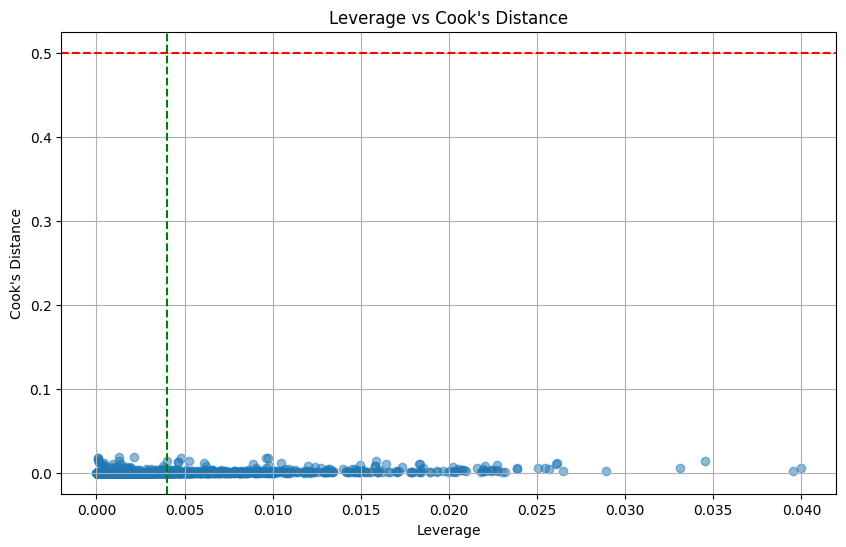

In [269]:
# Graficamos el leverage vs la Cook's Distance

plt.figure(figsize = (10, 6))
plt.scatter(leverage, cooks_d, alpha = 0.5)
plt.xlabel('Leverage')
plt.ylabel("Cook's Distance")
plt.title("Leverage vs Cook's Distance")
plt.axhline(0.5, color = 'red', linestyle = '--')
plt.axvline(2 * np.mean(leverage), color = 'green', linestyle = '--')
plt.grid()
plt.show()

In [270]:
# Umbrales

threshold_cooks = 4 / len(X_train_sm)  # Umbral para Cook's Distance
threshold_leverage = 2 * (X_train_sm.shape[1] + 1) / X_train_sm.shape[0]  # Regla para leverage

# Observaciones con alta influencia

outliers = np.where((cooks_d > threshold_cooks) | (leverage > threshold_leverage))[0]

# Mostramos los resultados

print(f"Observaciones influyentes detectadas: {len(outliers)}")
print("Índices de observaciones influyentes:", outliers)

Observaciones influyentes detectadas: 499
Índices de observaciones influyentes: [   3   16   23   35   39   40   55   57   78   82   92  100  104  110
  116  119  126  139  145  151  155  156  164  169  179  180  186  188
  192  202  221  225  226  240  244  263  285  287  292  293  294  297
  300  301  303  307  317  338  345  360  367  375  380  386  391  392
  399  402  413  414  426  432  437  441  457  461  463  472  474  493
  494  498  508  519  522  533  543  547  582  597  598  604  606  622
  626  629  630  649  656  659  662  665  671  676  680  684  686  701
  710  712  726  770  771  783  786  788  790  805  808  815  833  850
  854  859  861  874  878  882  884  890  904  914  918  922  925  929
  930  939  951  952  954  956  960  967  978 1003 1019 1031 1035 1045
 1058 1067 1081 1090 1097 1105 1127 1140 1153 1165 1170 1174 1184 1185
 1200 1217 1218 1219 1222 1237 1244 1250 1256 1269 1271 1285 1304 1328
 1330 1334 1335 1336 1342 1347 1349 1357 1358 1367 1371 1378 1380 13

**Evaluación de observaciones influyentes (Leverage y Cook’s Distance)**

**Gráfico Leverage vs Cook’s Distance**

- En el gráfico de dispersión de leverage contra la distancia de Cook, la mayoría de los puntos se encuentran por debajo de los umbrales de referencia establecidos:
  - Línea roja (Cook’s Distance = 0.5): Ninguna observación supera este umbral.
  - Línea verde (Leverage promedio × 2): La mayoría de las observaciones están dentro de los límites de leverage.

**Observaciones detectadas**

- Se detectaron 499 observaciones potencialmente influyentes utilizando los criterios de leverage y distancia de Cook.
- Aunque son muchas observaciones los valores individuales de leverage y Cook’s Distance son relativamente bajos (en su mayoría cercanos a cero).
- El modelo es robusto frente a observaciones atípicas extremas aunque podría explorarse si se desea realizar una mejora del modelo eliminando outliers.

**Recomendación**

No es necesario eliminar las observaciones influyentes detectadas en este análisis dado que no se identifican valores extremos fuera de los umbrales críticos, pero si se busca una optimización se puede realizar un análisis adicional filtrando las observaciones más extremas entre las 499 detectadas.

### **Bondad y ajuste general**

In [271]:
# Pseudo R^2 de McFadden

ll_model = result.llf    #Log-verosimilitud del modelo ajustado
ll_null = result.llnull  #Log-verosimilitud del modelo con constante

pseudo_r2 = 1 - (ll_model / ll_null)

print(f"Pseudo R^2 de McFadden: {pseudo_r2:.4f}")

# Estadístico de la razón de verosimilitud

lr_statistic = 2 * (ll_model - ll_null)
p_value_lr = chi2.sf(lr_statistic, df=result.df_model)

print(f"Estadístico de la razón de verosimilitud: {lr_statistic:.4f}")
print(f"Valor-p del test: {p_value_lr:.4f}")

# AUC en el set de entrenamiento
y_train_pred_proba = result.predict(X_train_sm)
auc_train = roc_auc_score(y_train, y_train_pred_proba)

print(f"AUC en el set de entrenamiento: {auc_train:.4f}")

Pseudo R^2 de McFadden: 0.5820
Estadístico de la razón de verosimilitud: 1288.1514
Valor-p del test: 0.0000
AUC en el set de entrenamiento: 0.9481


**Pseudo R^2 de McFadden:** 0.5820

Un valor de 0.5820 es considerado alto en modelos de regresión logística. Esto indica que el modelo logra explicar aproximadamente el 58.2% de la variabilidad en la variable objetivo respecto a un modelo sin predictores.

**Estadístico de la razón de verosimilitud:** 1288.1514

**Valor-p del test:** 0.0000

El valor-p indica que el modelo completo es estadísticamente significativo comparado con el modelo nulo y los predictores elegidos aportan valor y mejoran la predicción frente a un modelo que no usaría ninguna variable.

**AUC en el set de entrenamiento:** 0.9481

Significa que el modelo tiene una altísima capacidad de discriminar entre las dos clases (clientes que aceptan préstamo vs. los que no).

Con base en lo anterior:

El modelo presenta una excelente bondad de ajuste, con una alta explicación de la variabilidad y es estadísticamente significativo según el test de razón de verosimilitud, por lo cual el modelo está bien ajustado y es altamente predictivo sobre los datos de entrenamiento.

### **Evaluacion de Supuestos de la Regresión Logística**

1.  **Independencia de Errores**
    Se utilizó el estadístico de Durbin-Watson para evaluar la independencia de los residuos.

    **Valor obtenido:** 1.9879

    El valor está muy cerca de 2 lo que indica ausencia de autocorrelación entre los errores y se cumple el supuesto de independencia de errores.

2.  **Multicolinealidad**
    Se calcularon los Factores de Inflación de la Varianza (VIF).

    Todos los VIF (excepto la constante) son menores a 2 lo que indica una muy baja multicolinealidad entre los predictores y se cumple el supuesto de baja correlación entre los predictores.

3.  **Linealidad del Logit (Prueba de Box-Tidwell)**
    Se evaluó la relación lineal entre las variables continuas y el logit.

    Las variables `Income`, `CD.Account`, `Mortgage`, `Education_2` y `Education_3` mostraron p-valores significativos indicando **violación del supuesto de linealidad del logit**.

    `CCAvg` mostró un p-valor no significativo, lo que sugiere que **cumple el supuesto de linealidad**.

    No se cumple completamente el supuesto de linealidad para todas las variables lo cual podría afectar la precisión del modelo y la validez de la interpretación de los coeficientes.

4.  **Influencia de Observaciones (Cook's Distance y Leverage)**
    Se detectaron **499** observaciones como potencialmente influyentes, utilizando los criterios de leverage y Cook's Distance.

    Estas observaciones **pueden afectar la robustez del modelo** si no se gestionan adecuadamente.

5.  **Bondad de Ajuste General**

    -   **Pseudo R^2 de McFadden:** 0.5820

    -   **Test de razón de verosimilitud:** estadísticamente significativo (p-valor = 0.0000) lo que confirma que el modelo completo es mejor que el modelo nulo.

    -   **AUC en entrenamiento:** 0.9481 indíca una buena capacidad de discriminación.

    El modelo muestra una buena bondad de ajuste, alta capacidad predictiva y capacidad para distinguir entre las clases.

## **Hipótesis de por qué el set de datos podría requerir un tratamiento posterior**

Aunque el modelo de regresión logística muestra un excelente desempeño general existen evidencias que sugieren que el set de datos podría beneficiarse de un tratamiento adicional para mejorar aún más la robustez y precisión del modelo.

Planteamos la siguiente hipótesis:



> *El set de datos de Bankloan requiere un tratamiento posterior debido a la presencia de un número significativo de observaciones influyentes y problemas de no linealidad en algunas variables continuas los cuales podrían afectar la estabilidad del modelo.*

**Fundamentos**

-   **Observaciones Influyentes:**

    Se detectaron **499** observaciones potencialmente influyentes (según la Cook’s Distance y el Leverage).

    Aunque los valores individuales no son extremos, la cantidad de estos puntos podría ejercer una influencia en los coeficientes del modelo o en su varianza. Un tratamiento de outliers podría estabilizar el modelo.

-   **Violación Parcial de Linealidad del Logit:**

    La prueba de Box-Tidwell reveló que no todas las variables cumplen completamente el supuesto de linealidad con el logit de la variable objetivo.
    
    Esto podría introducir sesgos en la estimación y en la interpretación de efectos marginales.

**Acciones sugeridas a partir de la hipótesis:**

-   Aplicar tratamiento de *outliers* (Winsorización, transformaciones logarítmicas o eliminaciones).
-   Considerar transformar variables continuas (logaritmo, polinómicas, etc.) para mejorar su relación lineal con el logit, especialmente `Income`, `CD.Account`, `Mortgage`, `Education_2` y `Education_3`.
-   Aplicar modelos más robustos o técnicas de validación cruzada para reforzar la evaluación del modelo en presencia de observaciones influyentes.
-   Explorar modelos alternativos que manejen mejor las relaciones no lineales como árboles de decisión  si los problemas persisten tras el preprocesamiento.

# **Comparación de modelos analiticos**

## **Correlaciones respecto a la variable objetivo**

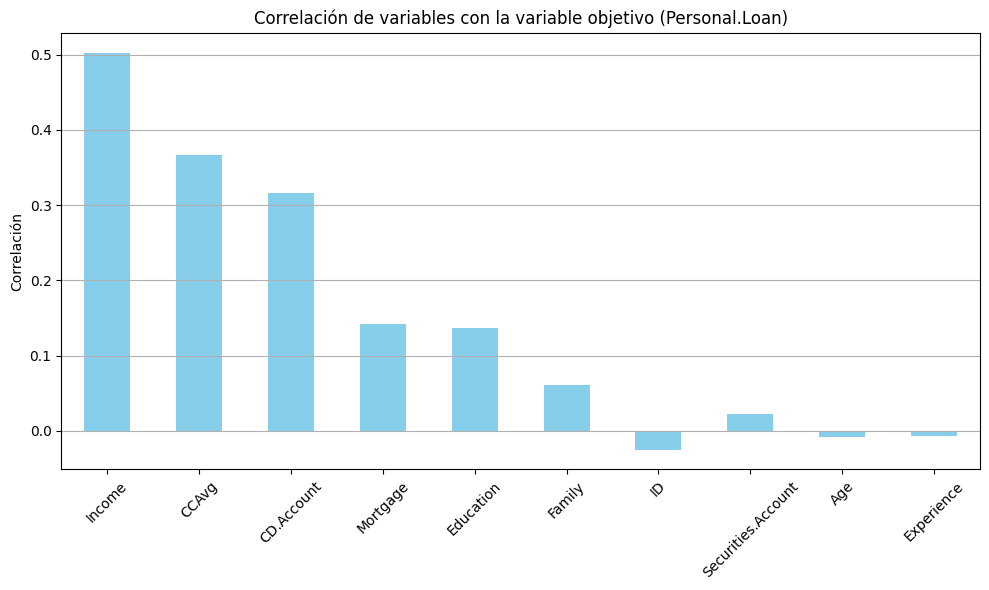

In [272]:
# Tomamos las 10 variables con mayor correlación

top_corr = final_corr_output.drop('Personal.Loan')[:10]

# Gráfico

plt.figure(figsize = (10,6))
top_corr.plot(kind = 'bar', color = 'skyblue')
plt.title('Correlación de variables con la variable objetivo (Personal.Loan)')
plt.ylabel('Correlación')
plt.xticks(rotation = 45)
plt.grid(axis = 'y')
plt.tight_layout()
plt.show()

## **Análisis de correlaciones y justificación de la comparación**

Con el objetivo de identificar las variables más relevantes para predecir la aceptación de un préstamo personal (`Personal.Loan`) se realizó un análisis de correlación entre esta variable objetivo y el resto de los atributos numéricos del conjunto de datos `Bank_Loan`.

El gráfico anterior muestra las 10 variables con mayor correlación (positiva o negativa) respecto a `Personal.Loan`. A partir de este análisis:

- La variable con mayor correlación positiva es `Income` con un valor cercano a 0.50 lo que indica que a mayor ingreso es más probable que se acepte un préstamo personal.

- Le siguen variables como `CCAvg` y `CD.Account` con correlaciones positivas.

- Variables como `Education` y `Mortgage` muestran correlaciones menores.

- Algunas variables como `ID`, `Age` o `Experience` presentan correlaciones casi nulas o incluso ligeramente negativas.

Estas observaciones indican que aunque existen algunas correlaciones lineales relevantes la relación entre las variables predictoras y la variable objetivo no es completamente lineal. Esto implica una posible limitación para modelos lineales como la Regresión Logística que podrían no capturar adecuadamente patrones más complejos en los datos.

Por lo tanto se considera adecuado comparar distintos algoritmos de clasificación binaria que puedan adaptarse tanto a relaciones lineales como no lineales entre variables:

- **Regresión Logística:** para establecer una línea base simple, explicable y fácil de interpretar.

- **Árbol de Decisión:** por su capacidad de capturar relaciones condicionales y estructurales en los datos.

- **Gradient Boosting Classifier:** por su desempeño predictivo al combinar múltiples árboles de manera secuencial.

- **Support Vector Machine:** es especialmente útil cuando la precisión es crítica y los datos están escalados.

El siguiente paso consistirá en aplicar estos modelos utilizando las variables más correlacionadas, evaluar su desempeño mediante métricas como precisión, recall, F1-score y AUC, y determinar cuál de ellos ofrece la mejor interpretabilidad y poder predictivo. Esta comparación será clave para seleccionar el modelo más adecuado de manera empírica más allá de su fundamentación teórica.

## **Regresion Logistica**

In [273]:
# Seleccion de variables con correlacion

corr = Bank_Loan.corr(numeric_only = True)
corr_output = corr['Personal.Loan'].drop('Personal.Loan')
selected_features = corr_output.abs().sort_values(ascending = False).head(10).index.tolist()

X = Bank_Loan[selected_features]
y = Bank_Loan['Personal.Loan']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y[X.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, random_state = 42)

log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]

print("Reporte de clasificación - Regresión Logística:")
print(classification_report(y_test, y_pred))

Reporte de clasificación - Regresión Logística:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1343
           1       0.84      0.59      0.69       157

    accuracy                           0.95      1500
   macro avg       0.90      0.79      0.83      1500
weighted avg       0.94      0.95      0.94      1500



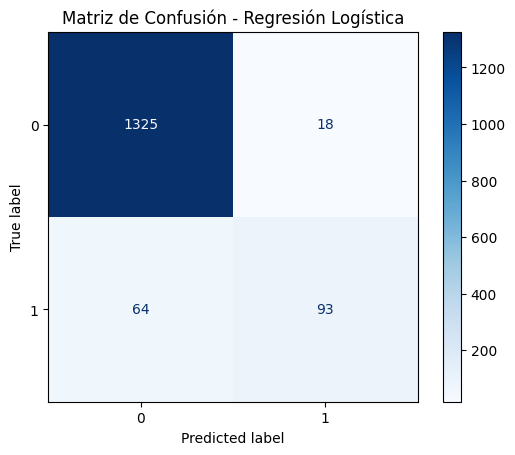

In [274]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

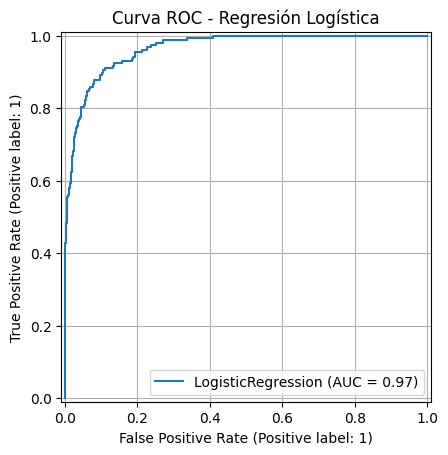

In [275]:
RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
plt.title("Curva ROC - Regresión Logística")
plt.grid()
plt.show()

La Regresión Logística utilizada como modelo base mostró un excelente desempeño general en la predicción de la variable objetivo `Personal.Loan` alcanzando una precisión total del 95% y un AUC de 0.97 lo cual indica capacidad de discriminación entre clases.

Sin embargo al analizar más a fondo los resultados por clase se observan que:

- El modelo predice muy bien la clase negativa (0, es decir clientes que no solicitaron el préstamo) con un recall de 0.99 y un F1-score de 0.97.

- Para la clase positiva (1, es decir clientes que sí solicitaron el préstamo) el rendimiento es limitado  con un recall de 0.59 y F1-score de 0.69.

- Esto implica que aunque el modelo identifica correctamente una buena parte de los positivos aún se escapan más del 40% de ellos lo que puede ser crítico si el objetivo es maximizar la captación o atención de clientes interesados.

La Regresión Logística es una excelente opción como modelo base por su simplicidad, interpretabilidad y precisión general. Sin embargo su capacidad para detectar correctamente a los clientes que sí solicitan préstamos es limitada frente a clases desbalanceadas o patrones no lineales. Por ello se sugiere comparar su rendimiento con modelos más flexibles como Árboles de Decisión o Gradient Boosting que podrían mejorar la sensibilidad del modelo.

## **Árbol de Decisión**

In [276]:
X = Bank_Loan[selected_features]
y = Bank_Loan['Personal.Loan']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y[X.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)
y_prob_tree = tree_clf.predict_proba(X_test)[:,1]

print("Reporte de clasificación - Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))

Reporte de clasificación - Árbol de Decisión:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.92      0.89      0.90       157

    accuracy                           0.98      1500
   macro avg       0.95      0.94      0.95      1500
weighted avg       0.98      0.98      0.98      1500



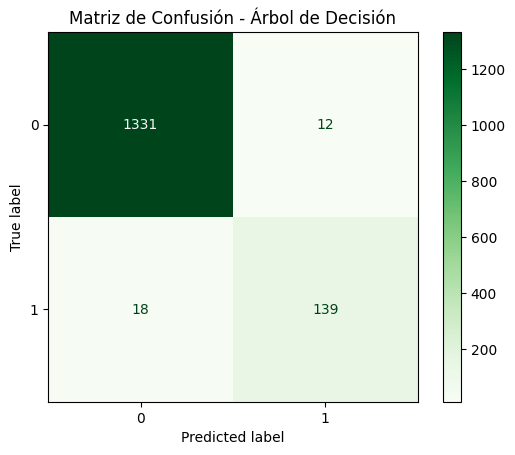

In [277]:
ConfusionMatrixDisplay.from_estimator(tree_clf, X_test, y_test, cmap='Greens')
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

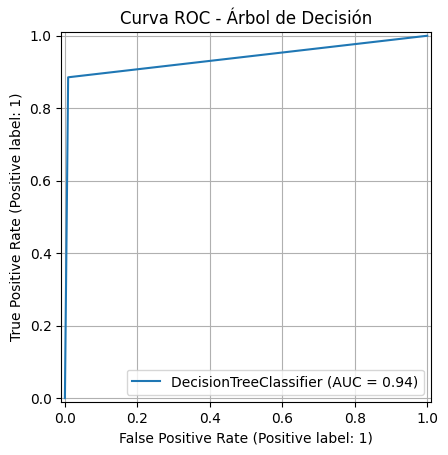

In [278]:
RocCurveDisplay.from_estimator(tree_clf, X_test, y_test)
plt.title("Curva ROC - Árbol de Decisión")
plt.grid()
plt.show()

El Árbol de Decisión mostró un desempeño sobresaliente en la predicción de la variable `Personal.Loan` con una precisión del 98% y un AUC de 0.94.

Lo más destacable es su capacidad para detectar correctamente casos positivos (clase 1) donde alcanza un recall de 0.89 y un F1-score de 0.90 superando al modelo de Regresión Logística. Además el modelo también mantiene un alto rendimiento para la clase negativa (0) con un F1-score de 0.99.

Estos resultados indican que el Árbol de Decisión es capaz de aprender estructuras complejas y relaciones no lineales.

El Árbol de Decisión representa una mejora significativa respecto al modelo logístico en términos de detección de la clase positiva. Esto lo convierte en una herramienta muy útil si el objetivo es identificar correctamente a los clientes que sí están interesados en obtener un préstamo. Su desempeño es bueno incluso sin aplicar técnicas de balanceo adicionales.

## **Gradient Boosting Classifier**

In [279]:
# Preparar X e y

X = Bank_Loan[selected_features]
y = Bank_Loan['Personal.Loan']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y[X.index]

# Escalar

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir entre entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Entrenar modelo

gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)

# Predicciones

y_pred_gb = gb_clf.predict(X_test)
y_prob_gb = gb_clf.predict_proba(X_test)[:,1]

# Reporte de clasificación

print("Reporte de clasificación - Gradient Boosting:")
print(classification_report(y_test, y_pred_gb))

Reporte de clasificación - Gradient Boosting:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1343
           1       0.98      0.93      0.95       157

    accuracy                           0.99      1500
   macro avg       0.99      0.96      0.97      1500
weighted avg       0.99      0.99      0.99      1500



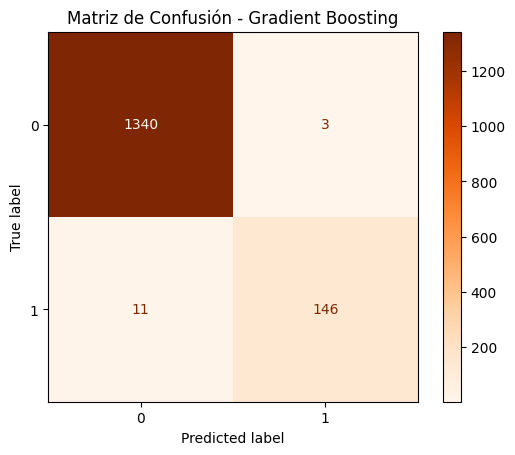

In [280]:
ConfusionMatrixDisplay.from_estimator(gb_clf, X_test, y_test, cmap='Oranges')
plt.title("Matriz de Confusión - Gradient Boosting")
plt.show()

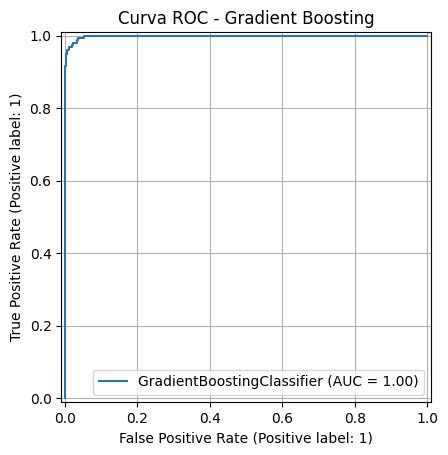

In [281]:
RocCurveDisplay.from_estimator(gb_clf, X_test, y_test)
plt.title("Curva ROC - Gradient Boosting")
plt.grid()
plt.show()

El modelo de Gradient Boosting mostró un buen desempeño en la predicción de la variable `Personal.Loan`, con un accuracy del 99% y un AUC de 1.00.

- Para la clase positiva (1) alcanzó un recall de 0.93 y un F1-score de 0.95 lo cual indica que el modelo identifica correctamente a la gran mayoría de los clientes que solicitaron un préstamo personal.

- Para la clase negativa (0) el rendimiento también fue sobresaliente, con un F1-score de 0.99.

- La curva ROC muestra una capacidad de discriminación casi perfecta entre clases.

El Gradient Boosting ofrece una alta sensibilidad y precisión en ambas clases. Aunque dado que el dataset presenta cierto desbalance, se explorará el uso de SMOTE para confirmar si es posible mejorar aún más el desempeño con menor volumen de datos o mayor sesgo.


## **Support Vector Machine**


In [282]:
# Preparar variables

X = Bank_Loan[selected_features]
y = Bank_Loan['Personal.Loan']

# Limpiar y escalar

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y[X.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separar en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Entrenar modelo SVM con probabilidad activada

svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train, y_train)

# Predicciones

y_pred_svm = svm_clf.predict(X_test)
y_prob_svm = svm_clf.predict_proba(X_test)[:, 1]

# Reporte

print("Reporte de clasificación - SVM:")
print(classification_report(y_test, y_pred_svm))

Reporte de clasificación - SVM:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1343
           1       0.98      0.76      0.86       157

    accuracy                           0.97      1500
   macro avg       0.98      0.88      0.92      1500
weighted avg       0.97      0.97      0.97      1500



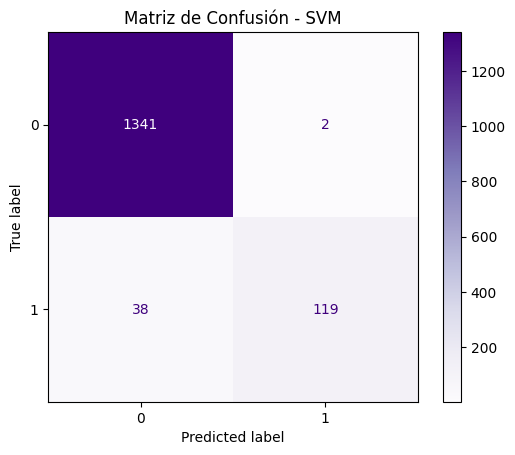

In [283]:
# Matriz de confusión

ConfusionMatrixDisplay.from_estimator(svm_clf, X_test, y_test, cmap='Purples')
plt.title("Matriz de Confusión - SVM")
plt.show()

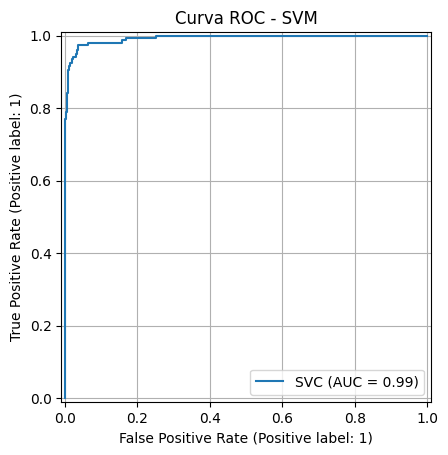

In [284]:
# Curva ROC

RocCurveDisplay.from_estimator(svm_clf, X_test, y_test)
plt.title("Curva ROC - SVM")
plt.grid()
plt.show()

El modelo de SVM demostró un excelente desempeño al predecir correctamente tanto la clase positiva como la negativa en la `variable Personal.Loan`.

El modelo logró identificar 119 de los 157 casos positivos con un recall del 0.76, la clase negativa fue predicha casi a la perfección con solo 2 falsos positivos y el AUC fue de 0.99 indicando una buena capacidad de discriminación entre clases.

A pesar de no superar por completo al Gradient Boosting el SVM es útil cuando la precisión es crítica.

## **Conclusiones y recomendaciones sobre el conjunto de datos original**

Se evaluaron cuatro modelos de clasificación binaria (Regresión Logística, Árbol de Decisión, Gradient Boosting y Support Vector Machine) para predecir la aceptación de préstamos personales (`Personal.Loan`) a partir de variables numéricas seleccionadas por su correlación.

Los resultados muestran que:

- La Regresión Logística ofrece una buena línea base y gran precisión general, pero sufre en la detección de casos positivos.

- El Árbol de Decisión mejora significativamente el balance entre clases y captura relaciones no lineales de forma efectiva.

 - El Gradient Boosting supera a todos los modelos en todas las métricas, logrando un AUC perfecto, alta precisión y recall para ambas clases.

 - El modelo de SVM representa una excelente alternativa a Gradient Boosting ofreciendo un alto desempeño con menor complejidad. Su robustez general y bajo número de falsos positivos lo hacen recomendable para aplicaciones donde el error tipo I debe minimizarse.

Recomendación:

Tras evaluar diversos modelos de clasificación para predecir la aceptación de préstamos personales (`Personal.Loan`) se concluye que Gradient Boosting ofrece el mejor desempeño general gracias a su alta precisión, recall y capacidad de discriminación (AUC = 1.00).

Sin embargo modelos como Support Vector Machine o el Árbol de Decisión también mostraron resultados altamente competitivos y pueden ser recomendables cuando haya una alta prioridad en la interpretabilidad o se requiera minimizar errores específicos como falsos positivos.

Por tanto se recomienda implementar Gradient Boosting como modelo principal de predicción, considerando como alternativas viables el uso de SVM o árboles en casos donde los recursos computacionales la transparencia del modelo o las necesidades de negocio así lo requieran.




| Modelo               | Precisión (True) | Recall (True) | F1-Score (True) | AUC   | Comentario                                                                    |
|----------------------|------------------|----------------|------------------|--------|--------------------------------------------------------------------------------|
| Regresión Logística  | 0.84             | 0.59           | 0.69             | 0.97   | Buen baseline, limitado para detectar positivos.                              |
| Árbol de Decisión    | 0.92             | 0.89           | 0.90             | 0.94   | Muy buen balance entre ambas clases.                                           |
| Gradient Boosting    | 0.98             | 0.93           | 0.95             | 1.00   | Máximo rendimiento. Ideal para detectar todos los casos.                      |
| Support Vector Machine | 0.97          | 0.76           | 0.85             | 0.99   | Alta precisión y excelente AUC. Alternativa sólida con bajo error tipo I.    |


## **Gráficas**

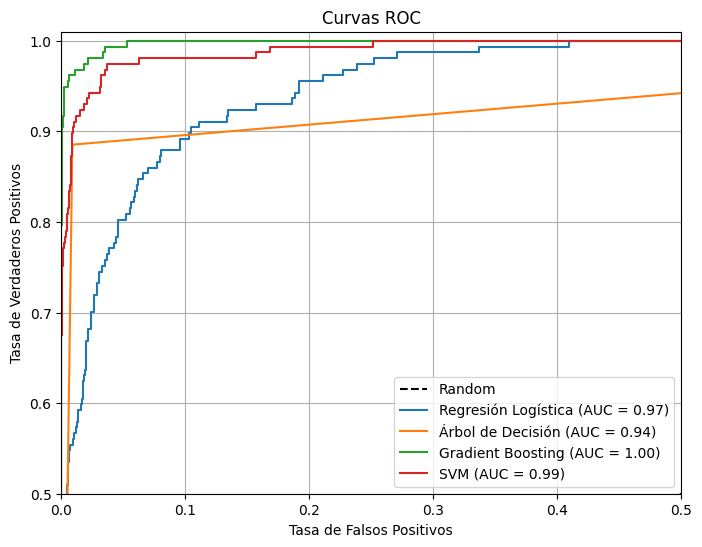

In [285]:
# ROC - Logit
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
auc_log = roc_auc_score(y_test, y_prob)

# ROC - Árbol
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

# ROC - Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

# ROC - SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize = (8, 6))
plt.xlim(0, 0.5)
plt.ylim(0.5, 1.01)
plt.plot([0, 1], [0, 1], 'k--', label = 'Random')
plt.plot(fpr_log, tpr_log, label = f'Regresión Logística (AUC = {auc_log:.2f})')
plt.plot(fpr_tree, tpr_tree, label = f'Árbol de Decisión (AUC = {auc_tree:.2f})')
plt.plot(fpr_gb, tpr_gb, label = f'Gradient Boosting (AUC = {auc_gb:.2f})')
plt.plot(fpr_svm, tpr_svm, label = f'SVM (AUC = {auc_svm:.2f})')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC')
plt.legend(loc = 'lower right')
plt.grid()
plt.show()

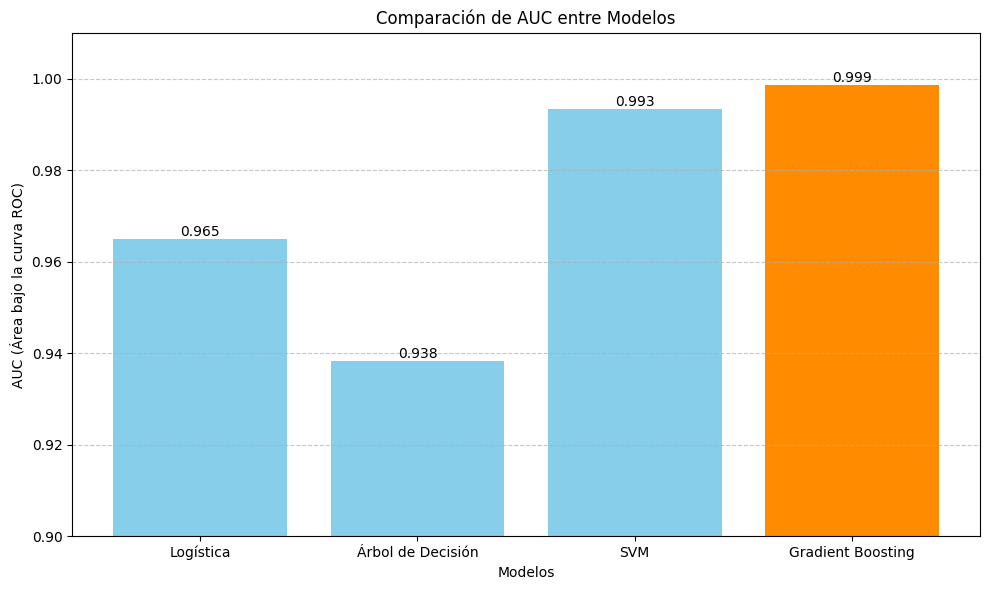

In [286]:
# AUC reales

models = ["Logística", "Árbol de Decisión", "SVM", "Gradient Boosting"]
auc_scores = [auc_log, auc_tree, auc_svm, auc_gb]

# Gráfico de barras

plt.figure(figsize = (10, 6))
colors = ['skyblue'] * (len(models) - 1) + ['darkorange']

bars = plt.bar(models, auc_scores, color=colors)

for bar, score in zip(bars, auc_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{score:.3f}",
        ha = 'center', va = 'bottom', fontsize = 10
    )

plt.ylim(0.9, 1.01)
plt.xlabel("Modelos")
plt.ylabel("AUC (Área bajo la curva ROC)")
plt.title("Comparación de AUC entre Modelos")
plt.xticks(rotation = 0)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()


## **Índice de Kolmogorov Smirnov**

In [287]:
def calculate_ks_index(y_true, y_pred_proba):
    df_probabilidades = pd.DataFrame({
        'y_true': y_true,
        'y_pred_proba': y_pred_proba
    })
    df_probabilidades = df_probabilidades.sort_values(by='y_pred_proba')
    df_probabilidades['cumsum_0'] = (df_probabilidades['y_true'] == 0).cumsum() / (df_probabilidades['y_true'] == 0).sum()
    df_probabilidades['cumsum_1'] = (df_probabilidades['y_true'] == 1).cumsum() / (df_probabilidades['y_true'] == 1).sum()
    df_probabilidades['ks'] = np.abs(df_probabilidades['cumsum_1'] - df_probabilidades['cumsum_0'])
    ks_statistic = df_probabilidades['ks'].max()
    return ks_statistic, df_probabilidades[['y_true', 'y_pred_proba', 'cumsum_0', 'cumsum_1', 'ks']]


In [288]:
# KS para Regresión Logística
ks_log, df_ks_log = calculate_ks_index(y_test, y_prob)
print(f"Índice KS - Regresión Logística: {ks_log:.3f}")

# KS para Árbol de Decisión
ks_tree, df_ks_tree = calculate_ks_index(y_test, y_prob_tree)
print(f"Índice KS - Árbol de Decisión: {ks_tree:.3f}")

# KS para Gradient Boosting
ks_gb, df_ks_gb = calculate_ks_index(y_test, y_prob_gb)
print(f"Índice KS - Gradient Boosting: {ks_gb:.3f}")

# KS para SVM
ks_svm, df_ks_svm = calculate_ks_index(y_test, y_prob_svm)
print(f"Índice KS - Support Vector Machine: {ks_svm:.3f}")


Índice KS - Regresión Logística: 0.800
Índice KS - Árbol de Decisión: 0.876
Índice KS - Gradient Boosting: 0.959
Índice KS - Support Vector Machine: 0.937


In [289]:
# Valores de KS calculados previamente

ks_scores = [ks_log, ks_tree, ks_svm, ks_gb]
models = ["Logística", "Árbol de Decisión", "SVM", "Gradient Boosting"]

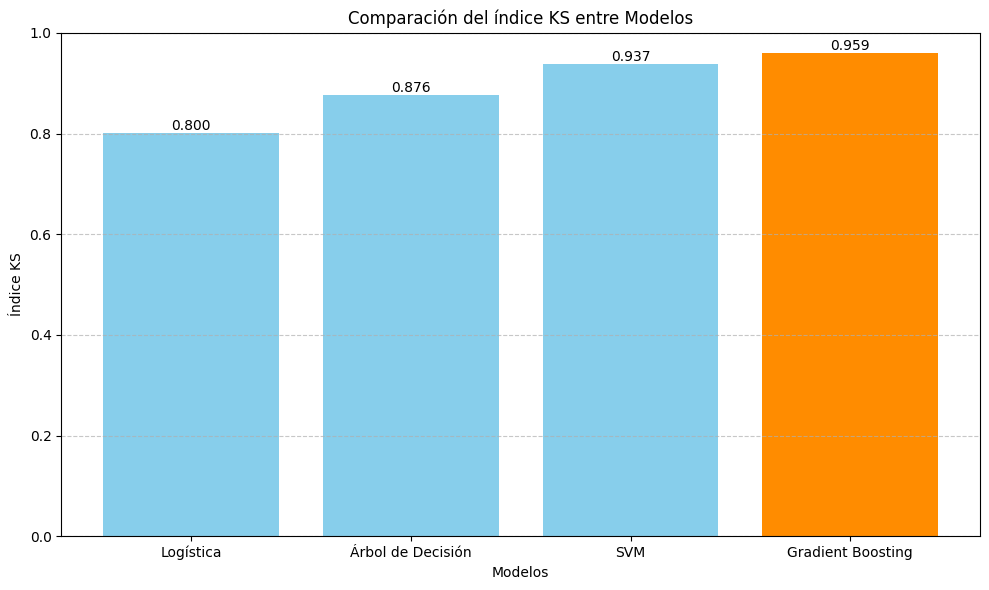

In [290]:
# Índice del mejor modelo
best_index = ks_scores.index(max(ks_scores))

colors = ['skyblue'] * len(models)
colors[best_index] = 'darkorange'

plt.figure(figsize = (10, 6))
bars = plt.bar(models, ks_scores, color=colors)

for bar, score in zip(bars, ks_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{score:.3f}",
        ha = 'center', va = 'bottom', fontsize = 10
    )

plt.ylim(0.0, 1.0)
plt.xlabel("Modelos")
plt.ylabel("Índice KS")
plt.title("Comparación del índice KS entre Modelos")
plt.xticks(rotation = 0)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()